In [210]:
import pandas as pd;
import numpy as np;
import matplotlib.pyplot as plt;
import seaborn as sns;

In [211]:
production = pd.read_csv("production_events_cleaned_T20_updated.csv")


# Test Case 1

In [212]:
print("Production:", production.columns)


Production: Index(['Event_ID', 'VIN', 'Work_Order', 'Model', 'Line', 'Station',
       'Timestamp', 'Part_Number', 'Supplier_Code_x', 'Operator_ID', 'Tool_ID',
       'Shift', 'BOM_Status', 'Supplier_Name_x', 'City_x', 'State_x',
       'Country_x', 'Supplier_Type_x', 'Quality_Rating_x',
       'On_Time_Delivery_%_x', 'PPM_Defects_x', 'Contact_Email_x',
       'Supplier_Status', 'Supplier_Name_y', 'City_y', 'State_y', 'Country_y',
       'Supplier_Type_y', 'Quality_Rating_y', 'On_Time_Delivery_%_y',
       'PPM_Defects_y', 'Contact_Email_y', 'Cycle_Time_Sec',
       'Cycle_Time_Status', 'VIN_Master', 'WO_VIN_Status', 'Visit_No',
       'Rework_Status', 'Derived_Shift', 'Shift_Status', 'Tool_Name',
       'Tool_Type', 'Plant_x', 'Calibration_Date', 'Next_Due_Date', 'Status_x',
       'Accuracy_%', 'Manufacturer', 'Serial_Number', 'Part_No_x', 'Part_Name',
       'Category', 'BOM_Version', 'Effective_Date', 'Unit_Cost_USD',
       'Supplier_Code_y', 'Status_y', 'Plant_y', 'Effective_From

In [213]:
production.head(10)

,Event_ID,VIN,Work_Order,Model,Line,Station,Timestamp,Part_Number,Supplier_Code_x,Operator_ID,...,Planned_Time_Minutes,Run_Time_Minutes,Downtime_Minutes,Ideal_Cycle_Time,Total_Units,Reject_Units,Good_Units,Availability,Performance,Quality
0,M8000,MA1A**********000,WO11000,Hatch Z,TRIM-1,STN-03,2026-03-02 02:50:00,ENG-1352,SUP-029,EMP345,...,480,452,28,1.11,481,15,466,0.9417,1.1812,0.9688
1,M11000,MA1A**********000,WO14000,Sedan X,TRIM-1,STN-03,2026-03-04 17:20:00,ENG-1363,SUP-157,EMP322,...,480,446,34,0.81,545,4,541,0.9292,0.9898,0.9927
2,M9000,MA1A**********000,WO12000,Sedan X,GA-1,STN-04,2026-03-02 23:40:00,ENG-1104,SUP-079,EMP306,...,480,462,18,0.85,476,4,472,0.9625,0.8758,0.9916
3,M10000,MA1A**********000,WO13000,Hatch Z,PAINT-1,STN-05,2026-03-03 20:30:00,ENG-1204,SUP-059,EMP392,...,480,460,20,1.19,457,7,450,0.9583,1.1822,0.9847
4,M9001,MA1A**********001,WO12001,SUV Pro,PAINT-1,STN-01,2026-03-02 23:41:00,ENG-1401,SUP-007,EMP269,...,480,459,21,1.10,507,19,488,0.9562,1.2150,0.9625
5,M8001,MA1A**********001,WO11001,Hatch Z,GA-1,STN-03,2026-03-02 02:51:00,ENG-1012,SUP-103,EMP212,...,480,453,27,1.09,462,11,451,0.9438,1.1117,0.9762
6,M10001,MA1A**********001,WO13001,Hatch Z,PAINT-1,STN-04,2026-03-03 20:31:00,ENG-1032,SUP-081,EMP241,...,480,451,29,1.11,452,18,434,0.9396,1.1125,0.9602
7,M11001,MA1A**********001,WO14001,SUV Pro,TRIM-1,STN-04,2026-03-04 17:21:00,ENG-1151,SUP-011,EMP293,...,480,479,1,0.95,485,8,477,0.9979,0.9619,0.9835
8,M7001,MA1A**********001,WO10001,Sedan X,GA-1,STN-05,2026-03-01 06:01:00,ENG-1379,SUP-140,EMP144,...,480,450,30,0.84,476,14,462,0.9375,0.8885,0.9706
9,M7002,MA1A**********002,WO10002,Sedan X,GA-1,STN-01,2026-03-01 06:59:00,ENG-1111,SUP-060,EMP358,...,480,472,8,1.06,532,7,525,0.9833,1.1947,0.9868


In [214]:

production["Availability"] = (
    production["Run_Time_Minutes"] /
    production["Planned_Time_Minutes"]
)

In [215]:
production["Performance"] = (
    production["Ideal_Cycle_Time"] *
    production["Total_Units"]
) / production["Run_Time_Minutes"]

In [216]:
production["Quality"] = (
    production["Good_Units"] /
    production["Total_Units"]
)

In [217]:
production["OEE"] = (
    production["Availability"] *
    production["Performance"] *
    production["Quality"]
)

In [218]:

production["OEE (%)"] = (
    production["OEE"] * 100
).round(2)

In [219]:
print(production[[
    "Machine_ID",
    "Availability",
    "Performance",
    "Quality",
    "OEE (%)"
]].head(10))

  Machine_ID  Availability  Performance   Quality  OEE (%)
0     MC-101      0.941667     1.181217  0.968815   107.76
1     MC-102      0.929167     0.989798  0.992661    91.29
2     MC-103      0.962500     0.875758  0.991597    83.58
3     MC-104      0.958333     1.182239  0.984683   111.56
4     MC-105      0.956250     1.215033  0.962525   111.83
5     MC-101      0.943750     1.111656  0.976190   102.41
6     MC-102      0.939583     1.112461  0.960177   100.36
7     MC-103      0.997917     0.961900  0.983505    94.41
8     MC-104      0.937500     0.888533  0.970588    80.85
9     MC-105      0.983333     1.194746  0.986842   115.94


In [220]:
production.to_csv("production_events_cleaned_T21_oee.csv", index=False)

print("\nOEE calculation completed successfully!")


OEE calculation completed successfully!


# Test Case 2

In [221]:
production = pd.read_csv("production_events_cleaned_T21_oee(1).csv")
quality = pd.read_csv("quality_inspection_cleaned_T18.csv")

In [222]:
data = production.merge(
    quality[["Event_ID", "Result"]],
    on="Event_ID",
    how="left"
)

In [223]:
data["Result"] = (
    data["Result"]
    .astype(str)
    .str.strip()
    .str.upper()
)

In [224]:
data["Pass"] = data["Result"].apply(
    lambda x: 1 if x == "PASS" else 0
)

In [225]:
fpy_station = (
    data.groupby("Station")
    .agg(
        Total_Units=("Event_ID", "count"),
        Passed_Units=("Pass", "sum")
    )
    .reset_index()
)

In [226]:
fpy_station["FPY (%)"] = (
    fpy_station["Passed_Units"] /
    fpy_station["Total_Units"] * 100
).round(2)

In [227]:
print("\nFPY by Station")
print(fpy_station)


FPY by Station
  Station  Total_Units  Passed_Units  FPY (%)
0  STN-01          849           273    32.16
1  STN-02          873           268    30.70
2  STN-03         1856           557    30.01
3  STN-04          946           305    32.24
4  STN-05         1723           540    31.34


In [228]:
fpy_line = (
    data.groupby("Line")
    .agg(
        Total_Units=("Event_ID", "count"),
        Passed_Units=("Pass", "sum")
    )
    .reset_index()
)

In [229]:
fpy_line["FPY (%)"] = (
    fpy_line["Passed_Units"] /
    fpy_line["Total_Units"] * 100
).round(2)

In [230]:
print("\nFPY by Line")
print(fpy_line)


FPY by Line
      Line  Total_Units  Passed_Units  FPY (%)
0     GA-1         1580           482    30.51
1     GA-2         1627           526    32.33
2  PAINT-1         1456           462    31.73
3   TRIM-1         1584           473    29.86


In [231]:
fpy_station.to_csv("FPY_By_Station.csv", index=False)
fpy_line.to_csv("FPY_By_Line.csv", index=False)

print("\nFPY calculation completed successfully!")


FPY calculation completed successfully!


# Test Case 3

In [232]:
production = pd.read_csv("production_events_cleaned_T21_oee.csv")
quality = pd.read_csv("quality_inspection_cleaned_T18.csv")

In [233]:
total_units = production["Event_ID"].nunique()

In [234]:
total_defects = quality[
    quality["Result"].str.upper() == "FAIL"
].shape[0]

In [235]:
dpu = round(total_defects / total_units, 4)

In [236]:
print("================================")
print("Defects Per Unit (DPU)")
print("================================")
print("Total Units :", total_units)
print("Total Defects :", total_defects)
print("DPU :", dpu)


Defects Per Unit (DPU)
Total Units : 5000
Total Defects : 2057
DPU : 0.4114


In [237]:
pareto = (
    quality[quality["Result"].str.upper() == "FAIL"]
    .groupby("Defect_Code")
    .size()
    .reset_index(name="Defect_Count")
)

In [238]:
pareto = pareto.sort_values(
    by="Defect_Count",
    ascending=False
)

In [239]:
pareto["Cumulative_Count"] = pareto["Defect_Count"].cumsum()

pareto["Cumulative_%"] = (
    pareto["Cumulative_Count"]
    / pareto["Defect_Count"].sum()
    * 100
).round(2)

In [240]:
print("\nPareto Analysis")
print(pareto)


Pareto Analysis
  Defect_Code  Defect_Count  Cumulative_Count  Cumulative_%
4        NONE           423               423         20.56
1        D002           414               837         40.69
0        D001           412              1249         60.72
3        D004           409              1658         80.60
2        D003           399              2057        100.00


In [241]:
pareto.to_csv("Pareto_Defect_Code.csv", index=False)

print("\nDPU and Pareto Analysis Completed Successfully!")


DPU and Pareto Analysis Completed Successfully!


# Test Case 4

In [242]:
production = pd.read_csv("production_events_cleaned_T21_oee(1).csv")

In [243]:
print(production.columns.tolist())

['Event_ID', 'VIN', 'Work_Order', 'Model', 'Line', 'Station', 'Timestamp', 'Part_Number', 'Supplier_Code_x', 'Operator_ID', 'Tool_ID', 'Shift', 'BOM_Status', 'Supplier_Name_x', 'City_x', 'State_x', 'Country_x', 'Supplier_Type_x', 'Quality_Rating_x', 'On_Time_Delivery_%_x', 'PPM_Defects_x', 'Contact_Email_x', 'Supplier_Status', 'Supplier_Name_y', 'City_y', 'State_y', 'Country_y', 'Supplier_Type_y', 'Quality_Rating_y', 'On_Time_Delivery_%_y', 'PPM_Defects_y', 'Contact_Email_y', 'Cycle_Time_Sec', 'Cycle_Time_Status', 'VIN_Master', 'WO_VIN_Status', 'Visit_No', 'Rework_Status', 'Derived_Shift', 'Shift_Status', 'Tool_Name', 'Tool_Type', 'Plant_x', 'Calibration_Date', 'Next_Due_Date', 'Status_x', 'Accuracy_%', 'Manufacturer', 'Serial_Number', 'Part_No_x', 'Part_Name', 'Category', 'BOM_Version', 'Effective_Date', 'Unit_Cost_USD', 'Supplier_Code_y', 'Status_y', 'Plant_y', 'Effective_From', 'Effective_To', 'Part_No_y', 'Machine_ID', 'Planned_Time_Minutes', 'Run_Time_Minutes', 'Downtime_Minutes',

In [244]:
production["Failure"] = production["Breakdown"].str.upper() == "YES"


In [245]:
mtbf = (
    production.groupby("Station")
    .agg(
        Total_Operating_Time=("Operating_Time_Minutes", "sum"),
        Number_of_Failures=("Failure", "sum")
    )
    .reset_index()
)

In [246]:
mtbf["MTBF (Minutes)"] = np.where(
    mtbf["Number_of_Failures"] == 0,
    np.nan,
    mtbf["Total_Operating_Time"] / mtbf["Number_of_Failures"]
)

In [247]:
repair_data = production[production["Failure"]]

In [248]:
mttr = (
    repair_data.groupby("Station")
    .agg(
        Total_Repair_Time=("Repair_Time_Minutes", "sum"),
        Number_of_Repairs=("Repair_Time_Minutes", "count")
    )
    .reset_index()
)

In [249]:
mttr["MTTR (Minutes)"] = (
    mttr["Total_Repair_Time"] /
    mttr["Number_of_Repairs"]
).round(2)

In [250]:
result = mtbf.merge(
    mttr[["Station", "MTTR (Minutes)"]],
    on="Station",
    how="left"
)

In [251]:
result["MTBF (Minutes)"] = result["MTBF (Minutes)"].round(2)

print(result)

  Station  Total_Operating_Time  Number_of_Failures  MTBF (Minutes)  \
0  STN-01                311885                  60         5198.08   
1  STN-02                314262                  48         6547.12   
2  STN-03                658776                 121         5444.43   
3  STN-04                343746                  66         5208.27   
4  STN-05                620500                 107         5799.07   

   MTTR (Minutes)  
0           54.65  
1           53.02  
2           50.02  
3           56.58  
4           52.72  


In [252]:
result.to_csv("MTBF_MTTR_By_Station.csv", index=False)

print("\nMTBF and MTTR calculation completed successfully!")


MTBF and MTTR calculation completed successfully!


# Test Case 5

In [253]:
production = pd.read_csv("production_events_cleaned_T21_oee(1).csv")


In [254]:
print(production.columns)

Index(['Event_ID', 'VIN', 'Work_Order', 'Model', 'Line', 'Station',
       'Timestamp', 'Part_Number', 'Supplier_Code_x', 'Operator_ID', 'Tool_ID',
       'Shift', 'BOM_Status', 'Supplier_Name_x', 'City_x', 'State_x',
       'Country_x', 'Supplier_Type_x', 'Quality_Rating_x',
       'On_Time_Delivery_%_x', 'PPM_Defects_x', 'Contact_Email_x',
       'Supplier_Status', 'Supplier_Name_y', 'City_y', 'State_y', 'Country_y',
       'Supplier_Type_y', 'Quality_Rating_y', 'On_Time_Delivery_%_y',
       'PPM_Defects_y', 'Contact_Email_y', 'Cycle_Time_Sec',
       'Cycle_Time_Status', 'VIN_Master', 'WO_VIN_Status', 'Visit_No',
       'Rework_Status', 'Derived_Shift', 'Shift_Status', 'Tool_Name',
       'Tool_Type', 'Plant_x', 'Calibration_Date', 'Next_Due_Date', 'Status_x',
       'Accuracy_%', 'Manufacturer', 'Serial_Number', 'Part_No_x', 'Part_Name',
       'Category', 'BOM_Version', 'Effective_Date', 'Unit_Cost_USD',
       'Supplier_Code_y', 'Status_y', 'Plant_y', 'Effective_From',
       'E

In [255]:
production["Cycle_Time_Minutes"] = (
    production["Run_Time_Minutes"] /
    production["Total_Units"]
).round(3)

In [256]:
cycle_time = (
    production.groupby("Station")
    .agg(
        Average_Cycle_Time=("Cycle_Time_Minutes", "mean"),
        Total_Units=("Total_Units", "sum")
    )
    .reset_index()
)

In [257]:
max_cycle = cycle_time["Average_Cycle_Time"].max()

cycle_time["Bottleneck"] = cycle_time["Average_Cycle_Time"].apply(
    lambda x: "Yes" if x == max_cycle else "No"
)

In [258]:
cycle_time = cycle_time.sort_values(
    by="Average_Cycle_Time",
    ascending=False
)

In [259]:
print("Cycle Time Distribution")
print(cycle_time)

Cycle Time Distribution
  Station  Average_Cycle_Time  Total_Units Bottleneck
4  STN-05            0.889616     722324.0        Yes
1  STN-02            0.888352     366042.0         No
3  STN-04            0.886187     402520.0         No
0  STN-01            0.885957     363816.0         No
2  STN-03            0.885063     771348.0         No


In [260]:
cycle_time.to_csv("Cycle_Time_Distribution.csv", index=False)

In [261]:
plt.figure(figsize=(10,5))

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

<BarContainer object of 5 artists>

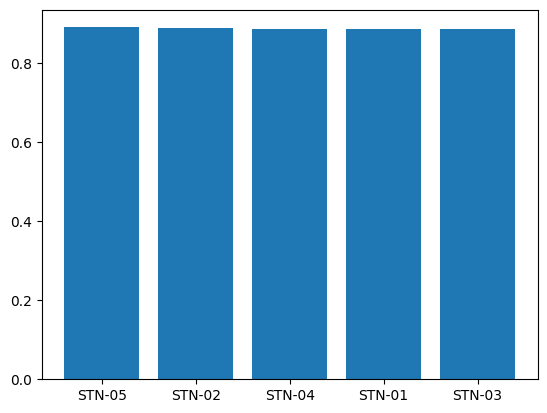

In [262]:
plt.bar(
    cycle_time["Station"],
    cycle_time["Average_Cycle_Time"]
)

(array([0. , 0.2, 0.4, 0.6, 0.8, 1. ]),
 [Text(0.0, 0, '0.0'),
  Text(0.2, 0, '0.2'),
  Text(0.4, 0, '0.4'),
  Text(0.6000000000000001, 0, '0.6'),
  Text(0.8, 0, '0.8'),
  Text(1.0, 0, '1.0')])

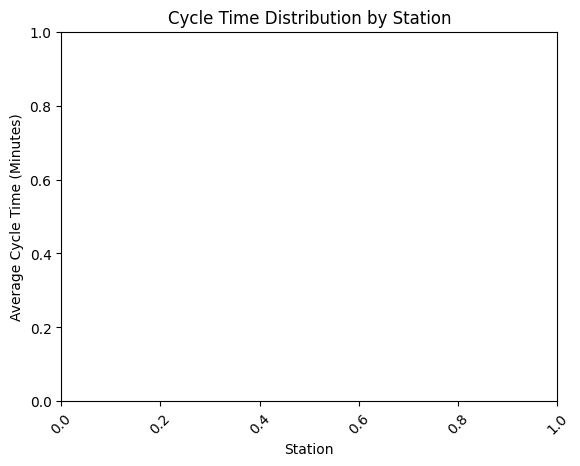

In [263]:
plt.title("Cycle Time Distribution by Station")
plt.xlabel("Station")
plt.ylabel("Average Cycle Time (Minutes)")
plt.xticks(rotation=45)

In [264]:
bottleneck = cycle_time[cycle_time["Bottleneck"] == "Yes"]

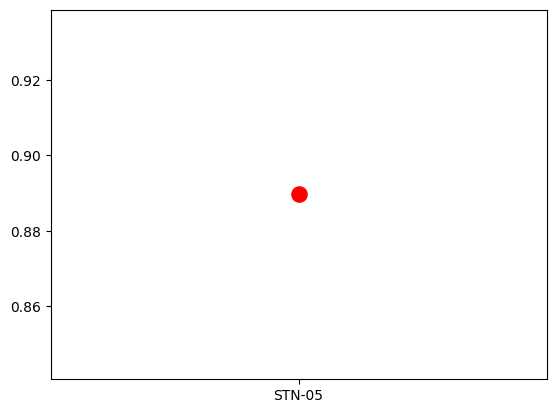

In [265]:
plt.scatter(
    bottleneck["Station"],
    bottleneck["Average_Cycle_Time"],
    color="red",
    s=120,
    label="Bottleneck"
)

C:\Users\chand\AppData\Local\Temp\ipykernel_22272\2265910356.py:1: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


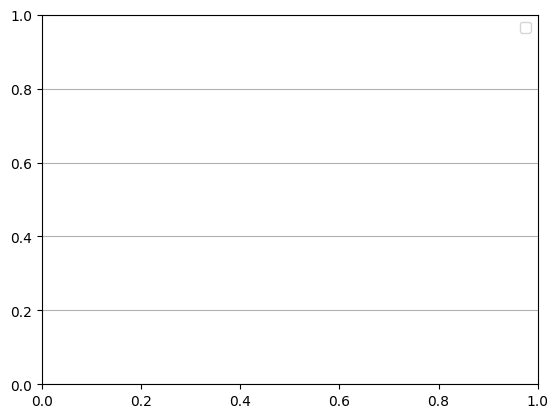


Cycle Time Analysis Completed Successfully!


In [266]:
plt.legend()
plt.grid(axis="y")

plt.show()

print("\nCycle Time Analysis Completed Successfully!")

# Test Case 6

In [267]:
sensor = pd.read_csv("sensor_readings_cleaned_T17.csv")

In [268]:
sensor["Temperature"] = (
    sensor["Temperature"]
    .astype(str)
    .str.extract(r'(\d+\.?\d*)')[0]
)

In [269]:
sensor["Temperature"] = pd.to_numeric(
    sensor["Temperature"],
    errors="coerce"
)

In [270]:
sensor = sensor.dropna(subset=["Temperature"])

In [271]:
group_size = 5

sensor["Group"] = sensor.index // group_size

In [272]:
xbar = sensor.groupby("Group")["Temperature"].mean()

In [273]:
# R (range)
R = sensor.groupby("Group")["Temperature"].apply(
    lambda x: x.max() - x.min()
)

In [274]:
plt.figure(figsize=(12,5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

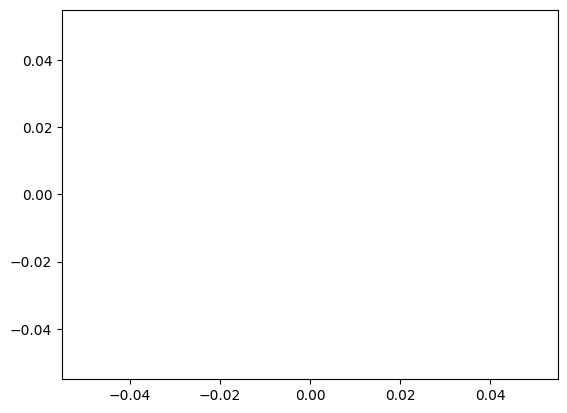

In [275]:
plt.plot(
    xbar.index,
    xbar.values,
    marker="o"
)

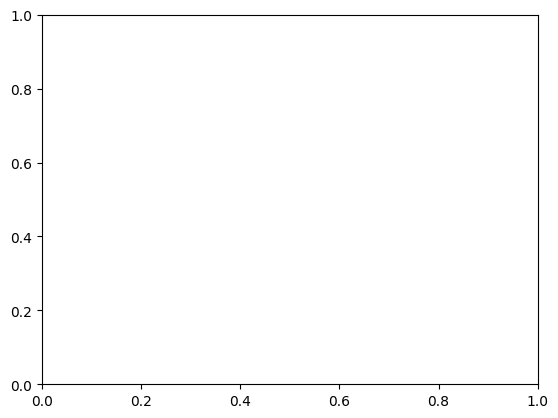

In [276]:
plt.axhline(
    xbar.mean(),
    color="red",
    linestyle="--",
    label="Center Line"
)

C:\Users\chand\AppData\Local\Temp\ipykernel_22272\944713372.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


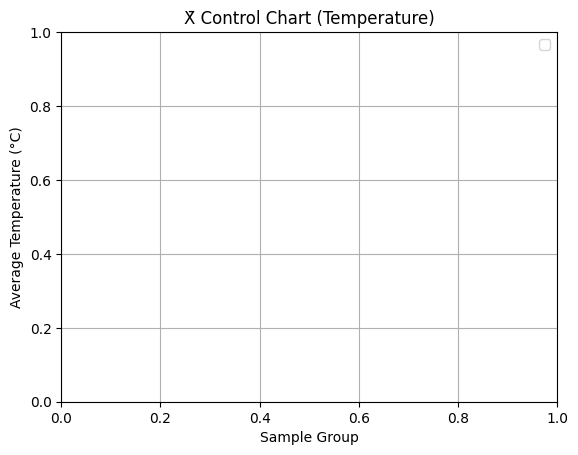

In [277]:
plt.title("X̄ Control Chart (Temperature)")
plt.xlabel("Sample Group")
plt.ylabel("Average Temperature (°C)")
plt.legend()
plt.grid(True)

plt.show()

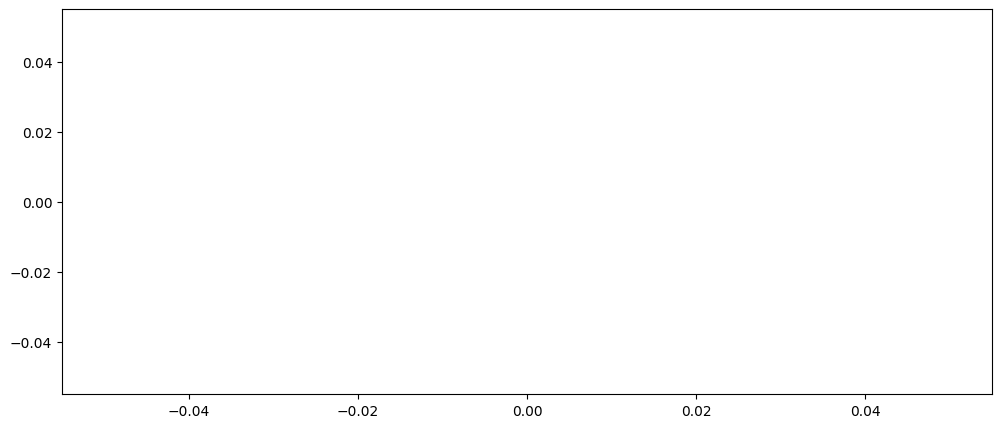

In [278]:
plt.figure(figsize=(12,5))

plt.plot(
    R.index,
    R.values,
    marker="o"
)

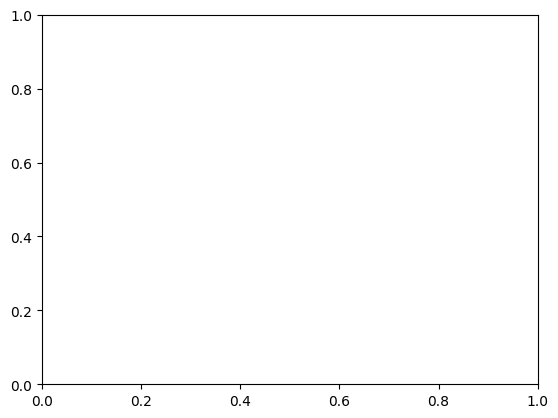

In [279]:
plt.axhline(
    R.mean(),
    color="red",
    linestyle="--",
    label="Center Line"
)

C:\Users\chand\AppData\Local\Temp\ipykernel_22272\4044002804.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


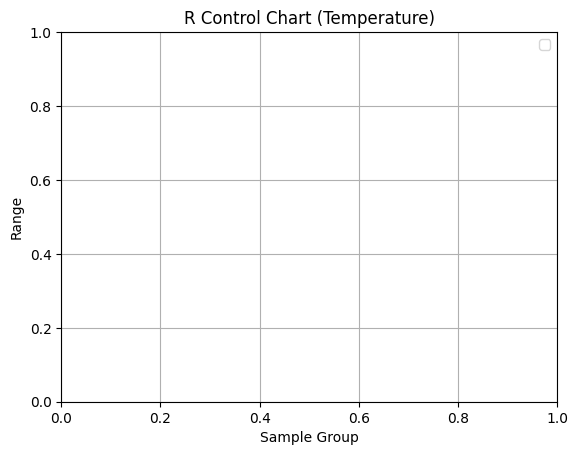

In [280]:
plt.title("R Control Chart (Temperature)")
plt.xlabel("Sample Group")
plt.ylabel("Range")
plt.legend()
plt.grid(True)

In [281]:
plt.show()


In [282]:
print("Average Temperature =", round(xbar.mean(),2))
print("Average Range =", round(R.mean(),2))

Average Temperature = nan
Average Range = nan


# Test Case 7

In [283]:
production = pd.read_csv("production_events_cleaned_T21_oee(1).csv")
supplier = pd.read_csv("supplier_master.csv")
bom = pd.read_csv("bom_master.csv")
warranty = pd.read_csv("warranty_claims.csv")

In [284]:
trace = production.merge(
    supplier,
    left_on="Supplier_Code_x",
    right_on="Supplier_Code",
    how="left"
)

In [285]:
trace = trace.merge(
    bom,
    on=["Part_Number", "Supplier_Code"],
    how="left"
)

In [286]:
print(warranty.columns)
print(production.columns)
print(supplier.columns)
print(bom.columns)


Index(['WC1016', 'MA1AB100000000016', '2026-05-14', 'F016', 'Clutch Wear',
       '640', 'City Cars', 'Clutch Plate Replaced', 'Closed', '3'],
      dtype='object')
Index(['Event_ID', 'VIN', 'Work_Order', 'Model', 'Line', 'Station',
       'Timestamp', 'Part_Number', 'Supplier_Code_x', 'Operator_ID', 'Tool_ID',
       'Shift', 'BOM_Status', 'Supplier_Name_x', 'City_x', 'State_x',
       'Country_x', 'Supplier_Type_x', 'Quality_Rating_x',
       'On_Time_Delivery_%_x', 'PPM_Defects_x', 'Contact_Email_x',
       'Supplier_Status', 'Supplier_Name_y', 'City_y', 'State_y', 'Country_y',
       'Supplier_Type_y', 'Quality_Rating_y', 'On_Time_Delivery_%_y',
       'PPM_Defects_y', 'Contact_Email_y', 'Cycle_Time_Sec',
       'Cycle_Time_Status', 'VIN_Master', 'WO_VIN_Status', 'Visit_No',
       'Rework_Status', 'Derived_Shift', 'Shift_Status', 'Tool_Name',
       'Tool_Type', 'Plant_x', 'Calibration_Date', 'Next_Due_Date', 'Status_x',
       'Accuracy_%', 'Manufacturer', 'Serial_Number', 'Part_

In [287]:
warranty = pd.read_csv(
    "warranty_claims.csv",
    header=None,
    names=[
        "Claim_ID",
        "VIN",
        "Claim_Date",
        "Failure_Code",
        "Failure_Description",
        "Warranty_Cost",
        "Dealer_Name",
        "Resolution",
        "Claim_Status",
        "Days_to_Close"
    ]
)

print(warranty.head())

  Claim_ID                VIN  Claim_Date Failure_Code   Failure_Description  \
0   WC1016  MA1AB100000000016  2026-05-14         F016           Clutch Wear   
1   WC1017  MA1AB100000000017  2026-05-15         F017         Radiator Leak   
2   WC1018  MA1AB100000000018  2026-05-16         F018  Power Window Failure   
3   WC1019  MA1AB100000000019  2026-05-17         F019     ABS Warning Light   
4   WC1020  MA1AB100000000020  2026-05-18         F020           Oil Leakage   

   Warranty_Cost   Dealer_Name                 Resolution Claim_Status  \
0            640     City Cars      Clutch Plate Replaced       Closed   
1            980  Metro Motors          Radiator Replaced       Closed   
2            270    ABC Motors  Window Regulator Replaced       Closed   
3            510    Prime Auto        ABS Sensor Replaced       Closed   
4            760     City Cars            Gasket Replaced       Closed   

   Days_to_Close  
0              3  
1              4  
2              2 

In [288]:
trace = trace.merge(
    warranty,
    on="VIN",
    how="left"
)

In [289]:
print(trace.columns)

Index(['Event_ID', 'VIN', 'Work_Order', 'Model', 'Line', 'Station',
       'Timestamp', 'Part_Number', 'Supplier_Code_x', 'Operator_ID',
       ...
       'Effective_To_y', 'Claim_ID', 'Claim_Date', 'Failure_Code_y',
       'Failure_Description', 'Warranty_Cost', 'Dealer_Name', 'Resolution',
       'Claim_Status', 'Days_to_Close'],
      dtype='object', length=110)


In [290]:
traceability = trace[[
    "Supplier_Code_x",
    "Supplier_Name",
    "Part_Number",
    "VIN",
    "Claim_ID",
    "Failure_Code_y",
    "Warranty_Cost",
    "Claim_Status"
]]

traceability = traceability.rename(columns={
    "Supplier_Code_x": "Supplier_Code",
    "Failure_Code_y": "Failure_Code"
})

print(traceability.head())

traceability.to_csv("Traceability_Chain.csv", index=False)

  Supplier_Code      Supplier_Name Part_Number                VIN Claim_ID  \
0       SUP-029   Auto Supplier 29    ENG-1352  MA1A**********000      NaN   
1       SUP-157  Auto Supplier 157    ENG-1363  MA1A**********000      NaN   
2       SUP-079   Auto Supplier 79    ENG-1104  MA1A**********000      NaN   
3       SUP-059   Auto Supplier 59    ENG-1204  MA1A**********000      NaN   
4       SUP-007    Auto Supplier 7    ENG-1401  MA1A**********001      NaN   

  Failure_Code  Warranty_Cost Claim_Status  
0          NaN            NaN          NaN  
1          NaN            NaN          NaN  
2          NaN            NaN          NaN  
3          NaN            NaN          NaN  
4          NaN            NaN          NaN  


In [291]:
print(traceability.head(10))


  Supplier_Code      Supplier_Name Part_Number                VIN Claim_ID  \
0       SUP-029   Auto Supplier 29    ENG-1352  MA1A**********000      NaN   
1       SUP-157  Auto Supplier 157    ENG-1363  MA1A**********000      NaN   
2       SUP-079   Auto Supplier 79    ENG-1104  MA1A**********000      NaN   
3       SUP-059   Auto Supplier 59    ENG-1204  MA1A**********000      NaN   
4       SUP-007    Auto Supplier 7    ENG-1401  MA1A**********001      NaN   
5       SUP-103  Auto Supplier 103    ENG-1012  MA1A**********001      NaN   
6       SUP-081   Auto Supplier 81    ENG-1032  MA1A**********001      NaN   
7       SUP-011   Auto Supplier 11    ENG-1151  MA1A**********001      NaN   
8       SUP-140  Auto Supplier 140    ENG-1379  MA1A**********001      NaN   
9       SUP-060   Auto Supplier 60    ENG-1111  MA1A**********002      NaN   

  Failure_Code  Warranty_Cost Claim_Status  
0          NaN            NaN          NaN  
1          NaN            NaN          NaN  
2     

In [292]:
traceability.to_csv("Traceability_Chain.csv", index=False)

print("Traceability Chain Created Successfully!")

Traceability Chain Created Successfully!


# Test Case 8

In [293]:
production = pd.read_csv("production_events_cleaned_T21_oee(1).csv")

In [294]:
print(production.columns.tolist())

['Event_ID', 'VIN', 'Work_Order', 'Model', 'Line', 'Station', 'Timestamp', 'Part_Number', 'Supplier_Code_x', 'Operator_ID', 'Tool_ID', 'Shift', 'BOM_Status', 'Supplier_Name_x', 'City_x', 'State_x', 'Country_x', 'Supplier_Type_x', 'Quality_Rating_x', 'On_Time_Delivery_%_x', 'PPM_Defects_x', 'Contact_Email_x', 'Supplier_Status', 'Supplier_Name_y', 'City_y', 'State_y', 'Country_y', 'Supplier_Type_y', 'Quality_Rating_y', 'On_Time_Delivery_%_y', 'PPM_Defects_y', 'Contact_Email_y', 'Cycle_Time_Sec', 'Cycle_Time_Status', 'VIN_Master', 'WO_VIN_Status', 'Visit_No', 'Rework_Status', 'Derived_Shift', 'Shift_Status', 'Tool_Name', 'Tool_Type', 'Plant_x', 'Calibration_Date', 'Next_Due_Date', 'Status_x', 'Accuracy_%', 'Manufacturer', 'Serial_Number', 'Part_No_x', 'Part_Name', 'Category', 'BOM_Version', 'Effective_Date', 'Unit_Cost_USD', 'Supplier_Code_y', 'Status_y', 'Plant_y', 'Effective_From', 'Effective_To', 'Part_No_y', 'Machine_ID', 'Planned_Time_Minutes', 'Run_Time_Minutes', 'Downtime_Minutes',

In [295]:
production["Alert_Time"] = pd.to_datetime(
    production["Alert_Time"],
    errors="coerce"
)

In [296]:
production["Response_Time"] = pd.to_datetime(
    production["Response_Time"],
    errors="coerce"
)

In [297]:
production["Response_Time_Minutes"] = (
    production["Response_Time"] -
    production["Alert_Time"]
).dt.total_seconds() / 60

In [298]:
production = production.dropna(subset=["Response_Time_Minutes"])

In [299]:
andon_station = (
    production.groupby("Station")
    .agg(
        Total_Alerts=("Event_ID", "count"),
        Avg_Response_Time_Minutes=("Response_Time_Minutes", "mean"),
        Min_Response_Time=("Response_Time_Minutes", "min"),
        Max_Response_Time=("Response_Time_Minutes", "max")
    )
    .reset_index()
)

In [300]:
andon_station["Avg_Response_Time_Minutes"] = (
    andon_station["Avg_Response_Time_Minutes"]
).round(2)

In [301]:
print("\nAndon Response Time by Station")
print(andon_station)


Andon Response Time by Station
  Station  Total_Alerts  Avg_Response_Time_Minutes  Min_Response_Time  \
0  STN-01           693                       5.56                1.0   
1  STN-02           698                       5.45                1.0   
2  STN-03          1465                       5.57                1.0   
3  STN-04           765                       5.49                1.0   
4  STN-05          1379                       5.55                1.0   

   Max_Response_Time  
0               10.0  
1               10.0  
2               10.0  
3               10.0  
4               10.0  


In [302]:
andon_shift = (
    production.groupby("Shift")
    .agg(
        Total_Alerts=("Event_ID", "count"),
        Avg_Response_Time_Minutes=("Response_Time_Minutes", "mean")
    )
    .reset_index()
)

In [303]:
andon_shift["Avg_Response_Time_Minutes"] = (
    andon_shift["Avg_Response_Time_Minutes"]
).round(2)

In [304]:
print("\nAndon Response Time by Shift")
print(andon_shift)


Andon Response Time by Shift
  Shift  Total_Alerts  Avg_Response_Time_Minutes
0     A          1254                       5.62
1     B          1275                       5.55
2     C          1231                       5.45
3   NAN          1240                       5.52


In [305]:
andon_station.to_csv("Andon_Response_By_Station.csv", index=False)
andon_shift.to_csv("Andon_Response_By_Shift.csv", index=False)

print("\nAndon Alert Response Time Metrics Completed Successfully!")


Andon Alert Response Time Metrics Completed Successfully!


# Test Case 9

In [306]:
production = pd.read_csv("production_events_cleaned_T21_oee(1).csv")
quality = pd.read_csv("quality_inspection_cleaned_T18.csv")

In [307]:
warranty = pd.read_csv(
    "warranty_claims.csv",
    header=None,
    names=[
        "Claim_ID",
        "VIN",
        "Claim_Date",
        "Failure_Code",
        "Failure_Description",
        "Warranty_Cost",
        "Dealer_Name",
        "Resolution",
        "Claim_Status",
        "Days_to_Close"
    ]
)


In [308]:
SCRAP_COST_PER_UNIT = 500

scrap_units = production["Reject_Units"].sum()

scrap_cost = scrap_units * SCRAP_COST_PER_UNIT

In [309]:
REWORK_COST_PER_UNIT = 200

rework_units = (
    quality["Rework_Flag"]
    .astype(str)
    .str.upper()
    .eq("YES")
    .sum()
)

rework_cost = rework_units * REWORK_COST_PER_UNIT

In [310]:
warranty["Warranty_Cost"] = pd.to_numeric(
    warranty["Warranty_Cost"],
    errors="coerce"
)

warranty_cost = warranty["Warranty_Cost"].sum()

In [311]:
copq = scrap_cost + rework_cost + warranty_cost

print("========== COPQ ==========")
print("Scrap Units :", scrap_units)
print("Scrap Cost  : ₹", scrap_cost)

print("\nRework Units :", rework_units)
print("Rework Cost  : ₹", rework_cost)

print("\nWarranty Cost : ₹", warranty_cost)

print("\nTotal COPQ : ₹", copq)

========== COPQ ==========
Scrap Units : 49305.0
Scrap Cost  : ₹ 24652500.0

Rework Units : 0
Rework Cost  : ₹ 0

Warranty Cost : ₹ 68490

Total COPQ : ₹ 24720990.0


In [312]:
copq_summary = pd.DataFrame({
    "Metric": [
        "Scrap Cost",
        "Rework Cost",
        "Warranty Cost",
        "Total COPQ"
    ],
    "Amount": [
        scrap_cost,
        rework_cost,
        warranty_cost,
        copq
    ]
})

copq_summary.to_csv("COPQ_Summary.csv", index=False)

print("\nCOPQ calculation completed successfully!")


COPQ calculation completed successfully!


# Test Case 10

In [313]:
production = pd.read_csv("production_events_cleaned_T21_oee(1).csv")


In [314]:
production["Throughput"] = (
    production["Total_Units"] /
    production["Run_Time_Minutes"]
).round(2)

In [315]:
production["Cycle_Time"] = (
    production["Run_Time_Minutes"] /
    production["Total_Units"]
).round(2)

In [316]:
production["WIP"] = (
    production["Throughput"] *
    production["Cycle_Time"]
).round(2)

In [317]:
summary = (
    production.groupby("Station")
    .agg(
        Average_Throughput=("Throughput", "mean"),
        Average_Cycle_Time=("Cycle_Time", "mean"),
        Average_WIP=("WIP", "mean")
    )
    .reset_index()
)

summary = summary.round(2)

print(summary)

  Station  Average_Throughput  Average_Cycle_Time  Average_WIP
0  STN-01                1.14                0.89          1.0
1  STN-02                1.13                0.89          1.0
2  STN-03                1.14                0.89          1.0
3  STN-04                1.14                0.89          1.0
4  STN-05                1.13                0.89          1.0


In [318]:
summary.to_csv("Throughput_WIP_Diagnostics.csv", index=False)

<BarContainer object of 5 artists>

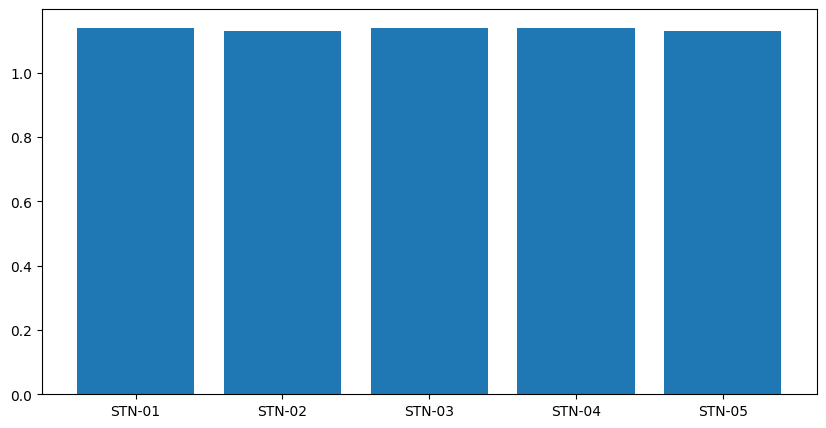

In [319]:
plt.figure(figsize=(10,5))

plt.bar(
    summary["Station"],
    summary["Average_Throughput"],
    label="Throughput"
)

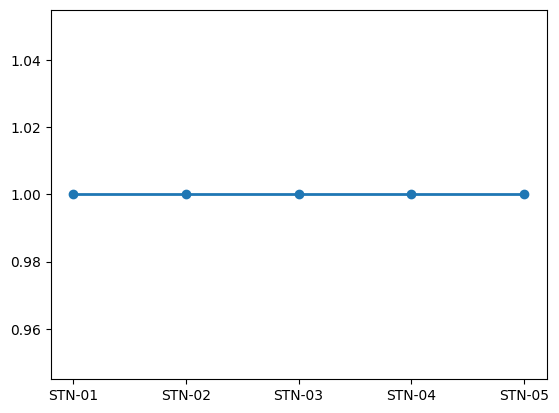

In [320]:
plt.plot(
    summary["Station"],
    summary["Average_WIP"],
    marker="o",
    linewidth=2,
    label="WIP"
)

C:\Users\chand\AppData\Local\Temp\ipykernel_22272\805931334.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


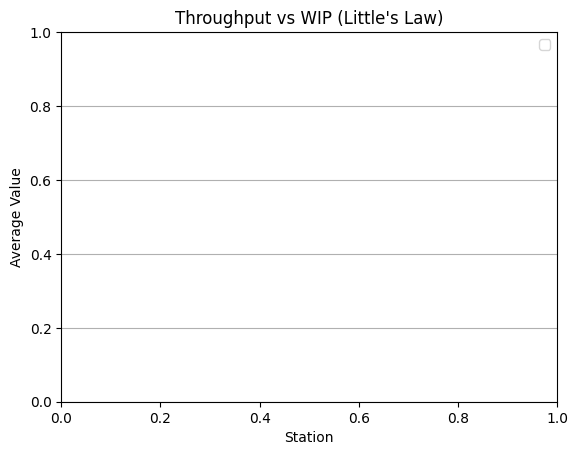


Little's Law Diagnostics Completed Successfully!


In [321]:
plt.title("Throughput vs WIP (Little's Law)")
plt.xlabel("Station")
plt.ylabel("Average Value")
plt.legend()
plt.grid(axis="y")

plt.show()

print("\nLittle's Law Diagnostics Completed Successfully!")